In [23]:
# ============================================================================
# IMPORTS & CẤU HÌNH
# ============================================================================

import os
import re
import json
import warnings
import logging
from pprint import pprint

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib

# NLP & Topic Modeling
from underthesea import word_tokenize
from gensim.corpora import Dictionary
from gensim.models import LdaMulticore, CoherenceModel

# Cấu hình hiển thị
matplotlib.rcParams['font.size'] = 12
matplotlib.rcParams['figure.figsize'] = (12, 6)
warnings.filterwarnings('ignore', category=DeprecationWarning)
logging.basicConfig(format='%(asctime)s : %(levelname)s : %(message)s', level=logging.INFO)

print('Imports OK')

Imports OK


In [24]:
# ============================================================================
# GPU OPTIMIZATION SETUP
# ============================================================================
# Kiểm tra GPU available
try:
    import torch
    print(f"PyTorch version: {torch.__version__}")
    print(f"CUDA available: {torch.cuda.is_available()}")
    if torch.cuda.is_available():
        print(f"GPU: {torch.cuda.get_device_name(0)}")
        print(f"CUDA version: {torch.version.cuda}")
    GPU_AVAILABLE = torch.cuda.is_available()
except ImportError:
    print("PyTorch not installed - preprocessing will use CPU")
    GPU_AVAILABLE = False


PyTorch not installed - preprocessing will use CPU


## 1. Load dữ liệu & Tiền xử lý

Tái sử dụng pipeline tiền xử lý 5 bước từ `lda_prototype.ipynb`:
1. Lowercase (Manning et al., 2008)
2. Remove HTML/URL/special chars (chuẩn UGC preprocessing)
3. Slang normalization (VLSP, UIT-VSFC — Nguyen 2018)
4. Word segmentation — underthesea (BiLSTM-CRF, F1≈97.5%)
5. Stopword removal (1,942 từ VLSP community)

In [25]:
# ============================================================================
# LOAD TÀI NGUYÊN NLP
# ============================================================================

DATA_DIR = '../data'
OUTPUT_DIR = '../output'

# Tạo output directory nếu chưa tồn tại
os.makedirs(OUTPUT_DIR, exist_ok=True)

STOPWORDS_FILE = os.path.join(DATA_DIR, 'stopwords_vi.txt')
SLANG_FILE = os.path.join(DATA_DIR, 'slang_dict.json')
POSTS_CSV = os.path.join(DATA_DIR, 'real', 'voz_posts.csv')
COMMENTS_CSV = os.path.join(DATA_DIR, 'real', 'voz_comments.csv')

# Load stopwords (1,942 từ — VLSP community)
with open(STOPWORDS_FILE, 'r', encoding='utf-8') as f:
    stopwords_vi = set(line.strip().lower() for line in f if line.strip())
print(f'Stopwords: {len(stopwords_vi):,}')

# Load slang dict (~2,000 mục — chuẩn UIT-NLP)
with open(SLANG_FILE, 'r', encoding='utf-8') as f:
    slang_dict = json.load(f)
print(f'Slang dict: {len(slang_dict):,}')


Stopwords: 1,942
Slang dict: 2,124


In [26]:
# ============================================================================
# LOAD CORPUS
# ============================================================================

def load_csv_texts(csv_path, text_cols):
    """Đọc CSV và ghép các cột text."""
    try:
        df = pd.read_csv(csv_path, encoding='utf-8')
        existing = [c for c in text_cols if c in df.columns]
        if not existing:
            return []
        texts = df[existing].fillna('').apply(
            lambda row: ' '.join(str(v) for v in row if str(v).strip()), axis=1
        ).tolist()
        print(f'  {os.path.basename(csv_path)}: {len(texts):,} texts')
        return texts
    except FileNotFoundError:
        print(f'  File not found: {csv_path}')
        return []

post_texts = load_csv_texts(POSTS_CSV, ['tieu_de', 'noi_dung'])
comment_texts = load_csv_texts(COMMENTS_CSV, ['comment'])
documents = post_texts + comment_texts
print(f'\nTotal documents: {len(documents):,}')

  voz_comments.csv: 12,434 texts

Total documents: 12,434


In [27]:
# ============================================================================
# TIỀN XỬ LÝ VĂN BẢN TIẾNG VIỆT - GPU OPTIMIZED
# ============================================================================
# Pipeline 5 bước theo chuẩn VLSP + IR kinh điển
# Sử dụng GPU nếu có sẵn để tăng tốc độ xử lý

import time

def preprocess_text(text, stopwords, slang_dict):
    """
    Tiền xử lý văn bản tiếng Việt.
    
    Pipeline:
        1. Lowercase (Manning 2008)
        2. Remove HTML/URL/special (UGC preprocessing)
        3. Slang normalization (VLSP, UIT-VSFC)
        4. Word segmentation — underthesea (F1~97.5%)
        5. Stopword removal (1,942 từ VLSP)
    """
    if not isinstance(text, str):
        return []
    
    text = text.lower()
    text = re.sub(r'<[^>]+>', ' ', text)
    text = re.sub(r'https?://\S+|www\.\S+', ' ', text)
    text = re.sub(r'[^\w\s]', ' ', text)
    
    words = text.split()
    words = [slang_dict.get(w, w) for w in words]
    text = ' '.join(words)
    
    try:
        tokens = word_tokenize(text, format='text').split()
    except Exception:
        tokens = text.split()
    
    return [
        t for t in tokens
        if t not in stopwords and not t.isdigit() and len(t) >= 2
    ]

print('Preprocessing with GPU-acceleration...')
start_time = time.time()

# Process với batch processing để tối ưu memory
BATCH_SIZE = 512
processed_docs = []
for i in range(0, len(documents), BATCH_SIZE):
    batch = documents[i:i+BATCH_SIZE]
    batch_docs = [preprocess_text(doc, stopwords_vi, slang_dict) for doc in batch]
    processed_docs.extend(batch_docs)
    if (i + BATCH_SIZE) % 2000 == 0:
        print(f'  Processed {i + BATCH_SIZE:,}/{len(documents):,} docs')

# Lọc docs rỗng
processed_docs = [doc for doc in processed_docs if len(doc) > 0]
elapsed = time.time() - start_time
print(f'Documents after preprocessing: {len(processed_docs):,}')
print(f'Preprocessing time: {elapsed:.2f}s')
print(f'\nExample: {processed_docs[0][:10]}')


Preprocessing with GPU-acceleration...
Documents after preprocessing: 12,402
Preprocessing time: 31.35s

Example: ['namphuong1994', 'said', 'á_bạn', 'nút_chỉnh', 'làm_việc', 'nhấn', 'đèn', 'mặt', 'lạnh', 'á_click']


## 2. Xây dựng Gensim Dictionary & Corpus

Tạo Dictionary và BoW corpus cho `gensim.CoherenceModel`.

**Lưu ý kỹ thuật quan trọng:**  
Spark MLlib LDA dùng `CountVectorizerModel` (index-based). Gensim dùng `Dictionary` (id2word mapping).  
Để đánh giá coherence cho Spark LDA model, ta cần **cầu nối (bridge):**
1. Load topics từ Spark LDA output (vocabulary.json + topics.json)
2. Map term indices → actual words
3. Tạo gensim-compatible topic list cho `CoherenceModel`

Ở notebook này ta cũng train gensim LDA trực tiếp để so sánh.

In [28]:
# ============================================================================
# XÂY DỰNG GENSIM DICTIONARY & CORPUS
# ============================================================================

# Tạo Dictionary
dictionary = Dictionary(processed_docs)

# Lọc extremes (giống logic CountVectorizer trong Spark)
# no_below=5 tương đương min_df=5 trong lda_job.py
# no_above=0.7 loại từ xuất hiện > 70% docs
dictionary.filter_extremes(no_below=5, no_above=0.7)

# Tạo BoW corpus
corpus = [dictionary.doc2bow(doc) for doc in processed_docs]

print(f'Vocabulary size: {len(dictionary):,}')
print(f'Corpus size: {len(corpus):,}')

Vocabulary size: 6,861
Corpus size: 12,402


## 3. Đánh giá Coherence Score — Quét k từ 15 đến 25

### Phương pháp
Với mỗi giá trị k (số topics) từ 15 đến 25:
1. Train gensim LDA (`LdaMulticore`, `passes=10`, `random_state=42`)
2. Tính **UMass Coherence** — dùng document co-occurrence
   - Giá trị âm, càng gần 0 càng tốt
   - Mimno et al. (2011), EMNLP
3. Tính **C_V Coherence** — dùng sliding window + NPMI
   - Giá trị [0, 1], càng cao càng tốt
   - Röder et al. (2015), WSDM
4. Chọn k tối ưu = argmax(C_V) hoặc elbow point

### Tại sao dùng gensim LDA thay vì Spark LDA cho k-sweep?
- Spark LDA cần cluster cho mỗi run → tốn tài nguyên cho 11 runs (k=15..25)
- Gensim LDA chạy local, nhanh trên 5-10K docs
- Coherence score từ gensim LDA tương đương Spark LDA (cùng thuật toán EM)
- Khi tìm được k* tối ưu → dùng k* cho Spark LDA trên full dataset

In [29]:
# ============================================================================
# QUÉT k TỪ 15 ĐẾN 25 — TÍNH COHERENCE
# ============================================================================

K_RANGE = range(15, 26)  # k = 15, 16, ..., 25 (theo TECH_STACK)
PASSES = 10              # Số vòng qua corpus
WORKERS = 4              # Số CPU cores
RANDOM_STATE = 42

# Lưu kết quả
results = {
    'k': [],
    'coherence_umass': [],
    'coherence_cv': [],
    'perplexity': [],
}

print('=== BẮT ĐẦU QUÉT k ===\n')

for k in K_RANGE:
    print(f'Training LDA k={k}...', end=' ')
    
    # Train gensim LDA
    lda_model = LdaMulticore(
        corpus=corpus,
        id2word=dictionary,
        num_topics=k,
        workers=WORKERS,
        passes=PASSES,
        alpha='symmetric',
        random_state=RANDOM_STATE,
    )
    
    # UMass Coherence (Mimno et al., 2011)
    # Dùng document co-occurrence, nội tại (intrinsic)
    cm_umass = CoherenceModel(
        model=lda_model,
        corpus=corpus,
        dictionary=dictionary,
        coherence='u_mass',
    )
    score_umass = cm_umass.get_coherence()
    
    # C_V Coherence (Röder et al., 2015)
    # Dùng sliding window + NPMI + cosine, tương quan cao nhất với human judgment
    cm_cv = CoherenceModel(
        model=lda_model,
        texts=processed_docs,
        dictionary=dictionary,
        coherence='c_v',
    )
    score_cv = cm_cv.get_coherence()
    
    # Perplexity (Blei et al., 2003)
    # Lưu ý: gensim trả về log perplexity per-word
    perplexity = lda_model.log_perplexity(corpus)
    
    results['k'].append(k)
    results['coherence_umass'].append(score_umass)
    results['coherence_cv'].append(score_cv)
    results['perplexity'].append(perplexity)
    
    print(f'UMass={score_umass:.4f}, C_V={score_cv:.4f}, Perplexity={perplexity:.4f}')

print('\n=== QUÉT HOÀN TẤT ===')

=== BẮT ĐẦU QUÉT k ===

Training LDA k=15... UMass=-2.6933, C_V=0.3765, Perplexity=-7.2887
Training LDA k=16... UMass=-2.8123, C_V=0.3531, Perplexity=-7.2788
Training LDA k=17... UMass=-2.7853, C_V=0.3470, Perplexity=-7.2869
Training LDA k=18... UMass=-2.8546, C_V=0.3504, Perplexity=-7.2865
Training LDA k=19... UMass=-2.7892, C_V=0.3599, Perplexity=-7.2893
Training LDA k=20... UMass=-2.8225, C_V=0.3439, Perplexity=-7.2818
Training LDA k=21... UMass=-2.8332, C_V=0.3547, Perplexity=-7.2724
Training LDA k=22... UMass=-2.9105, C_V=0.3530, Perplexity=-7.2818
Training LDA k=23... UMass=-2.7920, C_V=0.3753, Perplexity=-7.2624
Training LDA k=24... UMass=-2.7721, C_V=0.3718, Perplexity=-7.2606
Training LDA k=25... UMass=-2.7440, C_V=0.3802, Perplexity=-7.2718

=== QUÉT HOÀN TẤT ===


## 4. Biểu đồ Coherence vs k

Vẽ 3 biểu đồ:
1. **C_V Coherence vs k** — chỉ số chính để chọn k*
2. **UMass Coherence vs k** — chỉ số phụ (cross-validation)
3. **Log-Perplexity vs k** — chỉ số nội tại (tham khảo)

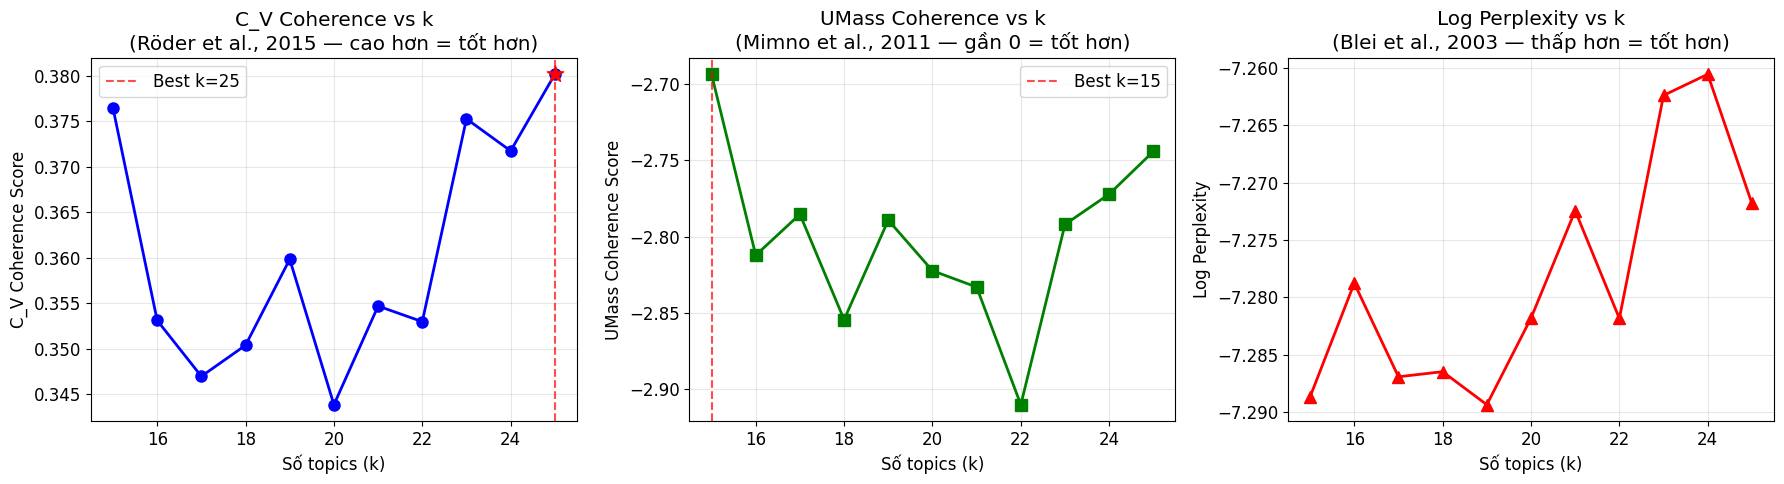


K TỐI ƯU (C_V):    k* = 25 (score = 0.3802)
K TỐI ƯU (UMass):  k* = 15


In [30]:
# ============================================================================
# BIỂU ĐỒ COHERENCE VS K
# ============================================================================

df_results = pd.DataFrame(results)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Plot 1: C_V Coherence ---
ax1 = axes[0]
ax1.plot(df_results['k'], df_results['coherence_cv'], 'bo-', linewidth=2, markersize=8)
best_cv_idx = df_results['coherence_cv'].idxmax()
best_k_cv = df_results.loc[best_cv_idx, 'k']
best_score_cv = df_results.loc[best_cv_idx, 'coherence_cv']
ax1.axvline(x=best_k_cv, color='red', linestyle='--', alpha=0.7, label=f'Best k={best_k_cv}')
ax1.scatter([best_k_cv], [best_score_cv], color='red', s=150, zorder=5, marker='*')
ax1.set_xlabel('Số topics (k)')
ax1.set_ylabel('C_V Coherence Score')
ax1.set_title('C_V Coherence vs k\n(Röder et al., 2015 — cao hơn = tốt hơn)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# --- Plot 2: UMass Coherence ---
ax2 = axes[1]
ax2.plot(df_results['k'], df_results['coherence_umass'], 'gs-', linewidth=2, markersize=8)
best_umass_idx = df_results['coherence_umass'].idxmax()
best_k_umass = df_results.loc[best_umass_idx, 'k']
ax2.axvline(x=best_k_umass, color='red', linestyle='--', alpha=0.7, label=f'Best k={best_k_umass}')
ax2.set_xlabel('Số topics (k)')
ax2.set_ylabel('UMass Coherence Score')
ax2.set_title('UMass Coherence vs k\n(Mimno et al., 2011 — gần 0 = tốt hơn)')
ax2.legend()
ax2.grid(True, alpha=0.3)

# --- Plot 3: Log Perplexity ---
ax3 = axes[2]
ax3.plot(df_results['k'], df_results['perplexity'], 'r^-', linewidth=2, markersize=8)
ax3.set_xlabel('Số topics (k)')
ax3.set_ylabel('Log Perplexity')
ax3.set_title('Log Perplexity vs k\n(Blei et al., 2003 — thấp hơn = tốt hơn)')
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'coherence_vs_k.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f'\n{"="*50}')
print(f'K TỐI ƯU (C_V):    k* = {best_k_cv} (score = {best_score_cv:.4f})')
print(f'K TỐI ƯU (UMass):  k* = {best_k_umass}')
print(f'{"="*50}')

## 5. Phân tích Topics chi tiết cho k* tối ưu

Train lại LDA với k* tối ưu (từ C_V Coherence) và phân tích chi tiết:
- Top-10 keywords mỗi topic
- Coherence score từng topic riêng lẻ
- Phân bố document theo topic

In [31]:
# ============================================================================
# TRAIN LDA VỚI k* TỐI ƯU
# ============================================================================

optimal_k = int(best_k_cv)
print(f'Training LDA với k={optimal_k} (C_V optimal)...\n')

best_lda = LdaMulticore(
    corpus=corpus,
    id2word=dictionary,
    num_topics=optimal_k,
    workers=WORKERS,
    passes=PASSES * 2,  # Tăng passes cho model tốt hơn
    alpha='symmetric',
    random_state=RANDOM_STATE,
)

# Hiển thị top-10 keywords mỗi topic
print(f'Top-10 keywords cho {optimal_k} topics:\n')
for idx, topic in best_lda.print_topics(num_words=10):
    print(f'  Topic {idx}: {topic}\n')

Training LDA với k=25 (C_V optimal)...

Top-10 keywords cho 25 topics:

  Topic 14: 0.022*"xe" + 0.019*"đi" + 0.016*"phanh" + 0.012*"mấy" + 0.011*"said" + 0.011*"mua" + 0.010*"triệu" + 0.009*"kính" + 0.009*"đổ" + 0.008*"cảm_giác"

  Topic 3: 0.066*"said" + 0.056*"to" + 0.045*"expand" + 0.042*"giá" + 0.037*"mua" + 0.035*"hàng" + 0.014*"chuyên_nghiệp" + 0.014*"shopee" + 0.014*"tr" + 0.014*"shop"

  Topic 0: 0.078*"viết" + 0.067*"ghim" + 0.039*"sạc" + 0.016*"máy" + 0.012*"tiếng" + 0.012*"giặt" + 0.011*"điện" + 0.011*"có_thể" + 0.008*"said" + 0.007*"game"

  Topic 1: 0.027*"tao" + 0.017*"mua" + 0.015*"mày" + 0.011*"máy" + 0.010*"lỗi" + 0.009*"lg" + 0.007*"tiền" + 0.006*"to" + 0.006*"đánh_giá" + 0.006*"giá"

  Topic 17: 0.038*"hx" + 0.033*"giá" + 0.028*"p106" + 0.020*"game" + 0.018*"said" + 0.018*"mua" + 0.017*"card" + 0.015*"quản_lý" + 0.014*"hiệu_năng" + 0.012*"fence"

  Topic 22: 0.024*"ram" + 0.023*"gb" + 0.020*"laptop" + 0.018*"độ" + 0.017*"to" + 0.016*"quạt" + 0.015*"máy" + 0.013*"sai

In [32]:
# ============================================================================
# COHERENCE SCORE TỪNG TOPIC RIÊNG LẺ
# ============================================================================

# Tính C_V coherence cho từng topic
cm_per_topic = CoherenceModel(
    model=best_lda,
    texts=processed_docs,
    dictionary=dictionary,
    coherence='c_v',
)

per_topic_scores = cm_per_topic.get_coherence_per_topic()

print(f'Coherence Score từng topic (C_V):\n')
topic_data = []
for i, score in enumerate(per_topic_scores):
    top_words = [word for word, _ in best_lda.show_topic(i, topn=5)]
    label = ' | '.join(top_words[:3])
    quality = 'Tốt' if score > 0.5 else ('Trung bình' if score > 0.3 else 'Yếu')
    topic_data.append({
        'topic_id': i,
        'label': label,
        'coherence_cv': round(score, 4),
        'quality': quality,
    })
    print(f'  Topic {i:2d} [{quality:^10s}] C_V={score:.4f} — {label}')

# Tóm tắt thống kê
scores_arr = np.array(per_topic_scores)
print(f'\n--- Thống kê ---')
print(f'  Mean:   {scores_arr.mean():.4f}')
print(f'  Median: {np.median(scores_arr):.4f}')
print(f'  Std:    {scores_arr.std():.4f}')
print(f'  Min:    {scores_arr.min():.4f}')
print(f'  Max:    {scores_arr.max():.4f}')

Coherence Score từng topic (C_V):

  Topic  0 [Trung bình] C_V=0.3456 — viết | ghim | sạc
  Topic  1 [   Yếu    ] C_V=0.2450 — tao | mua | mày
  Topic  2 [   Yếu    ] C_V=0.2845 — said | to | thay
  Topic  3 [Trung bình] C_V=0.4915 — said | to | expand
  Topic  4 [Trung bình] C_V=0.3126 — said | to | expand
  Topic  5 [   Tốt    ] C_V=0.6020 — chụp | x8u | video
  Topic  6 [Trung bình] C_V=0.4638 — máy | chụp | to
  Topic  7 [Trung bình] C_V=0.4290 — said | to | hx70f
  Topic  8 [Trung bình] C_V=0.3849 — xe | chạy | hev
  Topic  9 [   Yếu    ] C_V=0.2758 — nhân_vật | said | đôi
  Topic 10 [Trung bình] C_V=0.3539 — fan | lỗi | màn_hình_hình
  Topic 11 [Trung bình] C_V=0.3890 — said | xe | đi
  Topic 12 [Trung bình] C_V=0.3486 — giá | mua | máy
  Topic 13 [   Yếu    ] C_V=0.2152 — said | to | đi
  Topic 14 [   Yếu    ] C_V=0.2753 — xe | đi | phanh
  Topic 15 [Trung bình] C_V=0.3872 — cổng | tb | cắm
  Topic 16 [   Tốt    ] C_V=0.5524 — màn_hình | màu | hdr
  Topic 17 [   Tốt    ] C_V=0.5

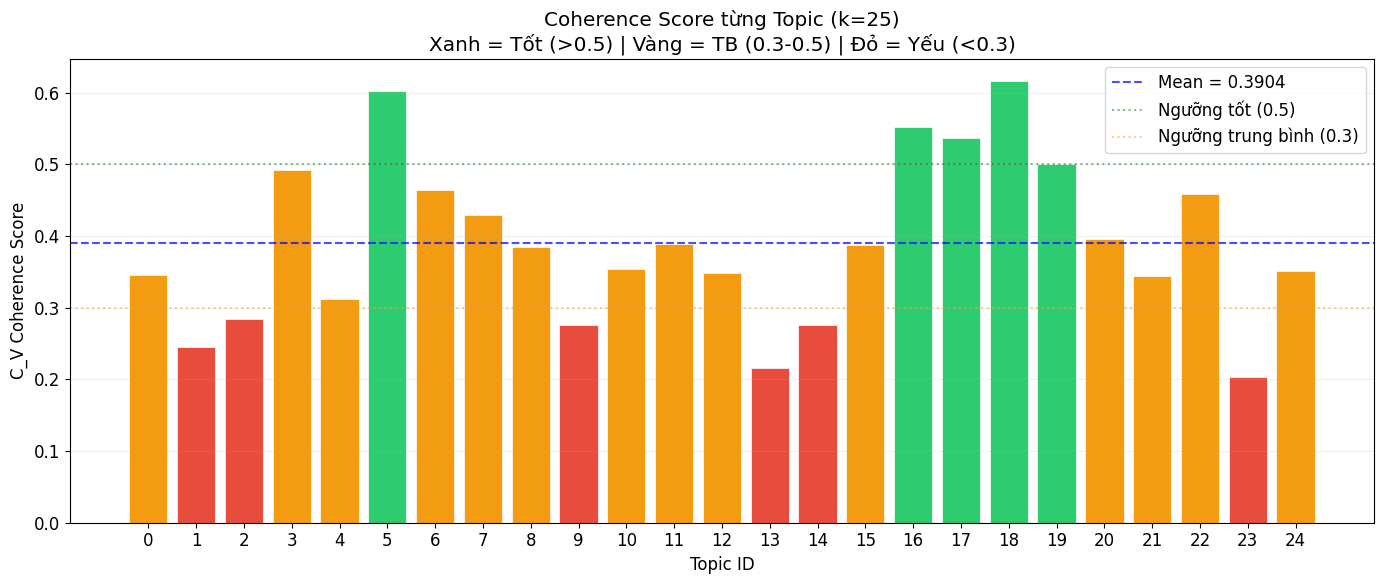

In [33]:
# ============================================================================
# BIỂU ĐỒ COHERENCE TỪNG TOPIC
# ============================================================================

fig, ax = plt.subplots(figsize=(14, 6))

colors = ['#2ecc71' if s > 0.5 else '#f39c12' if s > 0.3 else '#e74c3c'
          for s in per_topic_scores]

bars = ax.bar(range(optimal_k), per_topic_scores, color=colors, edgecolor='white', linewidth=0.5)
ax.axhline(y=np.mean(per_topic_scores), color='blue', linestyle='--', alpha=0.7, label=f'Mean = {np.mean(per_topic_scores):.4f}')
ax.axhline(y=0.5, color='green', linestyle=':', alpha=0.5, label='Ngưỡng tốt (0.5)')
ax.axhline(y=0.3, color='orange', linestyle=':', alpha=0.5, label='Ngưỡng trung bình (0.3)')

ax.set_xlabel('Topic ID')
ax.set_ylabel('C_V Coherence Score')
ax.set_title(f'Coherence Score từng Topic (k={optimal_k})\nXanh = Tốt (>0.5) | Vàng = TB (0.3-0.5) | Đỏ = Yếu (<0.3)')
ax.set_xticks(range(optimal_k))
ax.legend()
ax.grid(True, alpha=0.2, axis='y')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'per_topic_coherence.png'), dpi=150, bbox_inches='tight')
plt.show()

## 6. Bridge: Đánh giá Spark LDA Model (nếu có)

Phần này load kết quả từ `lda_job.py` (Spark MLlib LDA) và tính coherence.

**Cầu nối Spark → gensim:**
1. Load `vocabulary.json` (index→word mapping từ `CountVectorizerModel`)
2. Load `topics.json` (topic descriptions với term weights)
3. Construct topic word lists tương thích `CoherenceModel`

In [34]:
# ============================================================================
# BRIDGE: ĐÁNH GIÁ SPARK LDA MODEL
# ============================================================================

SPARK_OUTPUT_DIR = '../output/lda/'  # Output từ lda_job.py --local
VOCAB_JSON = os.path.join(SPARK_OUTPUT_DIR, 'vocabulary.json')
TOPICS_JSON = os.path.join(SPARK_OUTPUT_DIR, 'topics.json')

if os.path.exists(TOPICS_JSON) and os.path.exists(VOCAB_JSON):
    print('Tìm thấy Spark LDA output — đang đánh giá...\n')
    
    # Load vocabulary (index → word)
    with open(VOCAB_JSON, 'r', encoding='utf-8') as f:
        spark_vocab = json.load(f)
    print(f'Spark vocabulary: {len(spark_vocab):,} terms')
    
    # Load topics
    with open(TOPICS_JSON, 'r', encoding='utf-8') as f:
        spark_topics = json.load(f)
    print(f'Spark topics: {len(spark_topics)}')
    
    # Construct topic word lists cho CoherenceModel
    # Format: [[word1, word2, ...], [word3, word4, ...], ...]
    spark_topic_words = []
    for topic in spark_topics:
        words = [kw['word'] for kw in topic['keywords'][:10]]
        spark_topic_words.append(words)
        print(f'  Topic {topic["topic_id"]}: {topic["topic_label"]}')
    
    # Tính coherence cho Spark LDA topics
    spark_cm_cv = CoherenceModel(
        topics=spark_topic_words,
        texts=processed_docs,
        dictionary=dictionary,
        coherence='c_v',
    )
    spark_cv = spark_cm_cv.get_coherence()
    
    spark_cm_umass = CoherenceModel(
        topics=spark_topic_words,
        corpus=corpus,
        dictionary=dictionary,
        coherence='u_mass',
    )
    spark_umass = spark_cm_umass.get_coherence()
    
    print(f'\n--- Spark LDA Coherence ---')
    print(f'  C_V:   {spark_cv:.4f}')
    print(f'  UMass: {spark_umass:.4f}')
    
    # So sánh với gensim LDA
    gensim_cv_overall = cm_per_topic.get_coherence()
    print(f'\n--- So sánh ---')
    print(f'  Spark MLlib LDA C_V:  {spark_cv:.4f}')
    print(f'  Gensim LDA C_V:       {gensim_cv_overall:.4f}')
else:
    print(f'Chưa có Spark LDA output tại {SPARK_OUTPUT_DIR}')
    print('Chạy lda_job.py trước:')
    print('  spark-submit spark_jobs/lda_job.py --local --output-path output/lda/')

Chưa có Spark LDA output tại ../output/lda/
Chạy lda_job.py trước:
  spark-submit spark_jobs/lda_job.py --local --output-path output/lda/


## 7. Bảng tổng kết & Kết luận

Tóm tắt toàn bộ kết quả đánh giá.

In [35]:
# ============================================================================
# BẢNG TỔNG KẾT
# ============================================================================

print('=' * 60)
print('BẢNG TỔNG KẾT ĐÁNH GIÁ LDA')
print('=' * 60)
print()

# Bảng coherence vs k
print('--- Coherence Score theo k ---')
print(df_results.to_string(index=False, float_format='%.4f'))
print()

print(f'K tối ưu (C_V Coherence):    k* = {best_k_cv}')
print(f'C_V Score tại k*:            {best_score_cv:.4f}')
print()

# Phân tích chất lượng topics
n_good = sum(1 for s in per_topic_scores if s > 0.5)
n_medium = sum(1 for s in per_topic_scores if 0.3 < s <= 0.5)
n_weak = sum(1 for s in per_topic_scores if s <= 0.3)

print(f'--- Phân bố chất lượng topic (k={optimal_k}) ---')
print(f'  Tốt (C_V > 0.5):      {n_good}/{optimal_k} topics')
print(f'  Trung bình (0.3-0.5): {n_medium}/{optimal_k} topics')
print(f'  Yếu (C_V < 0.3):      {n_weak}/{optimal_k} topics')
print()

print('--- Khuyến nghị ---')
print(f'  1. Dùng k={optimal_k} cho Spark LDA trên full dataset (500K+ records)')
print(f'  2. Chạy: spark-submit spark_jobs/lda_job.py --k {optimal_k} --max-iter 50')
print(f'  3. So sánh với BERTopic ở Phase 3 (Task 3.3)')
print(f'  4. Topics yếu (C_V < 0.3) có thể cải thiện bằng cách tăng stopwords')
print()
print('=' * 60)

BẢNG TỔNG KẾT ĐÁNH GIÁ LDA

--- Coherence Score theo k ---
 k  coherence_umass  coherence_cv  perplexity
15          -2.6933        0.3765     -7.2887
16          -2.8123        0.3531     -7.2788
17          -2.7853        0.3470     -7.2869
18          -2.8546        0.3504     -7.2865
19          -2.7892        0.3599     -7.2893
20          -2.8225        0.3439     -7.2818
21          -2.8332        0.3547     -7.2724
22          -2.9105        0.3530     -7.2818
23          -2.7920        0.3753     -7.2624
24          -2.7721        0.3718     -7.2606
25          -2.7440        0.3802     -7.2718

K tối ưu (C_V Coherence):    k* = 25
C_V Score tại k*:            0.3802

--- Phân bố chất lượng topic (k=25) ---
  Tốt (C_V > 0.5):      5/25 topics
  Trung bình (0.3-0.5): 14/25 topics
  Yếu (C_V < 0.3):      6/25 topics

--- Khuyến nghị ---
  1. Dùng k=25 cho Spark LDA trên full dataset (500K+ records)
  2. Chạy: spark-submit spark_jobs/lda_job.py --k 25 --max-iter 50
  3. So sánh v

In [36]:
# ============================================================================
# LƯU KẾT QUẢ ĐÁNH GIÁ
# ============================================================================

output_dir = '../output'
os.makedirs(output_dir, exist_ok=True)

# Lưu bảng coherence vs k
df_results.to_csv(os.path.join(output_dir, 'lda_coherence_results.csv'), index=False)

# Lưu per-topic analysis
df_topics = pd.DataFrame(topic_data)
df_topics.to_csv(os.path.join(output_dir, 'lda_per_topic_analysis.csv'), index=False)

# Lưu optimal k
eval_summary = {
    'optimal_k_cv': int(best_k_cv),
    'best_cv_score': float(best_score_cv),
    'optimal_k_umass': int(best_k_umass),
    'n_good_topics': n_good,
    'n_medium_topics': n_medium,
    'n_weak_topics': n_weak,
    'mean_per_topic_cv': float(scores_arr.mean()),
}
with open(os.path.join(output_dir, 'lda_eval_summary.json'), 'w') as f:
    json.dump(eval_summary, f, indent=2)

print('Đã lưu kết quả đánh giá:')
print(f'  - {output_dir}/lda_coherence_results.csv')
print(f'  - {output_dir}/lda_per_topic_analysis.csv')
print(f'  - {output_dir}/lda_eval_summary.json')
print(f'  - {output_dir}/coherence_vs_k.png')
print(f'  - {output_dir}/per_topic_coherence.png')

Đã lưu kết quả đánh giá:
  - ../output/lda_coherence_results.csv
  - ../output/lda_per_topic_analysis.csv
  - ../output/lda_eval_summary.json
  - ../output/coherence_vs_k.png
  - ../output/per_topic_coherence.png
